### **PROJECT**

# Title: Cats vs Dogs Classification Project



### **Name: MEFTOUH Mohammed Dhiya Eddine**
### **ID: 20255387**



# Cats,Dogs Classification Project

## Objective
The goal of this project is to build a binary classifier that recognizes cats and dogs.

- Label 0: Cat
- Label 1: Dog

## Constraints
- CNNs are strictly forbidden.
- Classical machine learning methods are allowed.
- Scikit-learn can be used.

## General approach
In this notebook, I have used:
1. Load and inspect the image dataset.
2. Preprocess the images.
3. Extract features from the images.
4. Split the available data into training and validation sets.
5. Train and compare different machine learning models.
6. Select the best model.
7. Implement the required function cats_dogs_classification(image).

IN this project i have used two methods:
1-baseline model using resized raw pixel values and Logistic Regression.
2-An improved model using HOG feature extraction followed by dimensionality reduction and a linear Support Vector Machine.

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Explanation:
Here i have import first CV2 and os to navigate folders/files, and read and resize images, numpy will be used to manipulate matrices,and i have also used Sickitlearn to divide to available data into training and validation .
Standardscaler when feature scaling is needed.
These tools are sufficient to build a full classical machine learning pipeline for image classification.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cat_folder = "/content/drive/MyDrive/Datamachinelearning/data/Cat"
dog_folder = "/content/drive/MyDrive/Datamachinelearning/data/Dog/Dog"

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['5x5 B (1).jpg', '5x5 B.jpg', '1694783205286.jpg', 'Classroom', 'Untitled document (2).gdoc', 'Rec1.gdoc', 'CV..pdf', 'cv didine.pdf', 'SCAN0100.PDF', 'SCAN0101.PDF', 'italy.xlsx', 'Recitation 1.gdoc', 'mohammed dhiya eddine meftouh.pdf', 'Homework.pdf', 'Copy of Modeles-de-CV.com_Google-Docs_271.gdoc', 'group1.pdf', 'group 2.pdf', 'group 1.pdf', 'Language_Certificate (riadh).docx (1).pdf', 'Language_Certificate (riadh).docx (1).gdoc', 'Colab Notebooks', 'thesis', 'All transcripts of the years.pdf', 'Letter (3).gdoc', 'Resume (1).gdoc', 'Resume.gdoc', 'Letter (2).gdoc', 'Untitled document (1).gdoc', 'archive', 'cicIDS2017', 'cv (2).pdf', 'Untitled design (1).pptx', 'Language_Certificate.docx', 'french-3am22-3trim1_copy.pdf', 'french-3am24-3trim3_copy (1).pdf', 'french-3am24-3trim3_copy.pdf', 'french-1am24-3trim3_copy.pdf', 'Google AI Studio', 'final_project (3).pdf', 'CV new.pdf', 'motivation letter turkey.pdf', 'IMG_20250624_220111_copy.pdf', 'Formulaire_FR_0e7bcfa45f_copy (3).pdf', 

In [ ]:
import os

print("Cat exists:", os.path.exists(cat_folder))
print("Dog exists:", os.path.exists(dog_folder))

print("Number of cat images:", len(os.listdir(cat_folder)))
print("Number of dog images:", len(os.listdir(dog_folder)))

Cat exists: True
Dog exists: True
Number of cat images: 9375
Number of dog images: 9381


### Data Organization
The dataset is stored in two folders:
- one folder for cat images
- one folder for dog images

This folder-based organization makes labeling straightforward:
all images in the cat folder are assigned label 0, and all images in the dog folder are assigned label 1.

Before processing the dataset, the number of files in each folder is checked. This verification step is important to ensure that the dataset has been loaded correctly.

In [4]:
import numpy as np
import os

image_paths = []
labels = []

for filename in os.listdir(cat_folder):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        full_path = os.path.join(cat_folder, filename)
        image_paths.append(full_path)
        labels.append(0)

for filename in os.listdir(dog_folder):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        full_path = os.path.join(dog_folder, filename)
        image_paths.append(full_path)
        labels.append(1)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total number of images:", len(image_paths))
print("Total number of labels:", len(labels))
print("Number of cats:", np.sum(labels == 0))
print("Number of dogs:", np.sum(labels == 1))

Total number of images: 18756
Total number of labels: 18756
Number of cats: 9375
Number of dogs: 9381


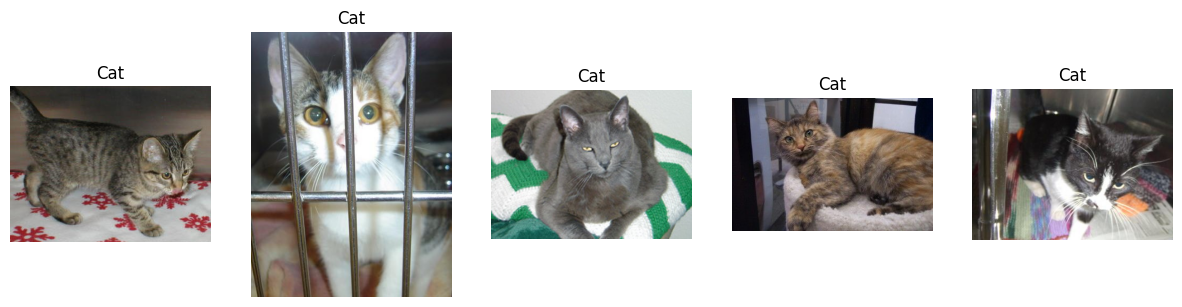

In [5]:
import cv2
import matplotlib.pyplot as plt

def show_samples(paths, labels, n=5):
    plt.figure(figsize=(15, 5))

    for i in range(n):
        img = cv2.imread(paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("Cat" if labels[i] == 0 else "Dog")

    plt.show()

show_samples(image_paths, labels, n=5)

Here i just visualize the first 5 cats , to see if the folder containing exact pictures, and  to observe the characteristics of the dataset before choosing a model.

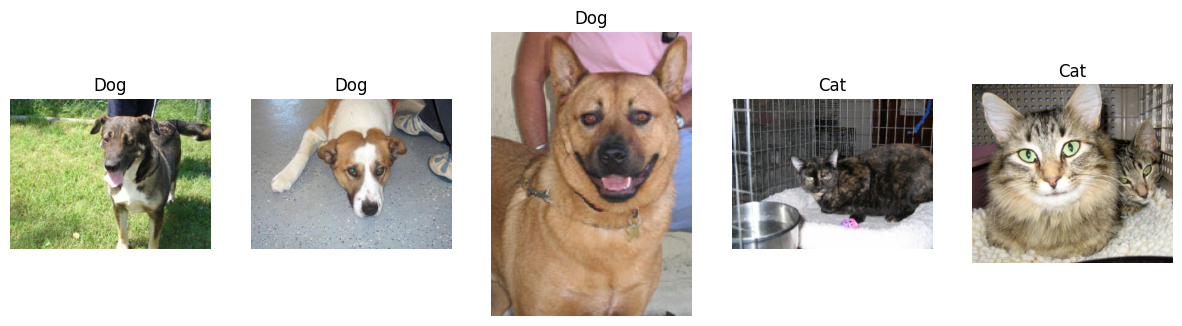

In [6]:
import random

def show_samples(paths, labels, n=5):
    indices = random.sample(range(len(paths)), n)

    plt.figure(figsize=(15, 5))

    for i, idx in enumerate(indices):
        img = cv2.imread(paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("Cat" if labels[idx] == 0 else "Dog")

    plt.show()

show_samples(image_paths, labels, n=5)

### Visualization of the Dataset

A few random images are displayed in order to better understand the data. This step is important because it allows us to observe the characteristics of the dataset before choosing a model.

Several observations can be made:
- the images have different sizes and resolutions
- the backgrounds are not uniform
- the animals appear in different poses

These observations justify the need for preprocessing before using a machine learning classifier.

In [21]:
import cv2
from tqdm import tqdm

IMG_SIZE = 64

X = []

for path in tqdm(image_paths):
    img = cv2.imread(path)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = img.flatten()

        X.append(img)

X = np.array(X)

print("Feature matrix shape:", X.shape)

  4%|▎         | 693/18756 [03:08<1:21:49,  3.68it/s]


KeyboardInterrupt: 

Remark: in this part i forgot to save the extracted features in drive , so each time need to run this cell again , which takes time.

As a first approach, each image is resized to a fixed size of 64 × 64 pixels and then flattened into a one-dimensional vector, because
Machine learning classifiers from scikit-learn expect all input samples to have the same number of features. Since the original images have different sizes, resizing is necessary to obtain a consistent input format.

1- For the size i have choosed 64*64 because:
This size is a compromise between:
- preserving enough visual information
- keeping computation manageable.

A larger size would preserve more detail but would also increase the number of input features and training time.

2-Flatten the images because:

Classical machine learning models do not directly process 2D or 3D image structures in the same way as CNNs. Therefore, each image must be transformed into a single feature vector.

For RGB images resized to 64 × 64, the total number of features is:
64 × 64 × 3 = 12288

### Now we will move to train/validation split of our data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)

NameError: name 'X' is not defined

**1- I will start using Logistic regression**

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

log_model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

#### I have used Logistic Regression first because:

Logistic Regression is a simple and widely used baseline classifier for binary classification. It is easy to implement, fast to train compared to more complex models, and provides a useful reference point for later improvements.

#### i have also used  StandardScaler because:
Raw pixel values can vary across dimensions. Standardization helps the optimization process and often improves convergence for linear models such as Logistic Regression.

The default number of iterations may not be enough for convergence when the feature space is large. Increasing max_iter ensures that the optimization algorithm has enough time to converge, this why i take the value equal to 1000.

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_log = log_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_log))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred_log))

NameError: name 'log_model' is not defined

### Results

The baseline model achieved a relatively low validation accuracy, around 55%.

From this result we can deduce that using raw flattened pixel values is not sufficient for this problem , since raw pixels contain too much low-level information and do not explicitly describe meaningful structures such as edges, textures, or shapes. In addition, cats and dogs can appear in very different positions, scales, and backgrounds, which makes raw-pixel classification difficult for a simple linear model.

Therefore, a more informative feature representation is needed.

# 2- Second Method.

In [7]:
from skimage.feature import hog
import cv2
import numpy as np
from tqdm import tqdm

In [ ]:
import cv2
import numpy as np
from tqdm import tqdm
from skimage.feature import hog

X_hog = []
IMG_SIZE = 64

for path in tqdm(image_paths):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

save_folder = "/content/drive/MyDrive/Datamachinelearning/data"

np.save(save_folder + "/X_hog.npy", X_hog)
np.save(save_folder + "/labels.npy", labels)

print("HOG features and labels saved successfully.")

  2%|▏         | 419/18756 [00:10<07:28, 40.91it/s]


KeyboardInterrupt: 

### Improved Feature Representation: HOG

To improve the model, i have used histogram of Oriented Gradients (HOG) features extracted from the images.

#### I have uses HOG because:
HOG is a hand-crafted feature descriptor that summarizes the distribution of edge directions in local image regions.

This is useful because animal recognition depends strongly on:
- contours
- local shapes
- texture patterns
- head and body structure

Compared to raw pixels, HOG provides a more meaningful representation for classical machine learning models.

#### Firstly i converted images to grayscale:
HOG is mainly based on gradient and edge information, not on color. Converting to grayscale simplifies the representation and reduces computational cost while keeping the most relevant structural information.

Then As with the baseline, all images must have the same size so that the HOG descriptor has the same length for every sample.

#### Finally i  saved the HOG features because:
HOG extraction over thousands of images is computationally expensive. Since the notebook may be executed multiple times in Colab, the extracted features are saved to disk to avoid recomputing them every time. This makes experimentation much faster and more practical.

For the parameters:
#### orientations = 9
This means that gradient directions are grouped into 9 bins.
This is a standard choice in HOG and gives a good balance between directional detail and feature size.

#### pixels_per_cell = (8, 8)
The image is divided into small cells of 8 × 8 pixels.
Inside each cell, a histogram of gradient directions is computed.
This size is commonly used because it is small enough to capture local details but large enough to remain stable.

#### cells_per_block = (2, 2)
Neighboring cells are grouped into blocks of 2 × 2 cells for normalization.
This improves robustness to local illumination and contrast changes.

#### block_norm = L2-Hys
This normalization scheme is widely used for HOG because it improves descriptor stability and often leads to better performance in practice.

In [8]:
import numpy as np

save_folder = "/content/drive/MyDrive/Datamachinelearning/data"

X_hog = np.load(save_folder + "/X_hog.npy")
labels = np.load(save_folder + "/labels.npy")

print("X_hog shape:", X_hog.shape)
print("labels shape:", labels.shape)

X_hog shape: (18756, 1764)
labels shape: (18756,)


In [9]:
from sklearn.model_selection import train_test_split

X_train_hog, X_val_hog, y_train_hog, y_val_hog = train_test_split(
    X_hog,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("X_train_hog shape:", X_train_hog.shape)
print("X_val_hog shape:", X_val_hog.shape)
print("y_train_hog shape:", y_train_hog.shape)
print("y_val_hog shape:", y_val_hog.shape)

X_train_hog shape: (15004, 1764)
X_val_hog shape: (3752, 1764)
y_train_hog shape: (15004,)
y_val_hog shape: (3752,)


I have used SVM directly , but it takes a lot of time since dataset is large, so i will try another solution to get a good accuaracy and try to reduce time, by using PCA , and Linear SVM.

In [10]:
from sklearn.decomposition import PCA
import joblib
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    PCA(n_components=0.95, random_state=42),
    LinearSVC(random_state=42, max_iter=5000)
)

model.fit(X_train_hog, y_train_hog)
joblib.dump(model, "/content/drive/MyDrive/Datamachinelearning/data/final_cats_dogs_model.pkl")

print("Training finished and model saved.")

Training finished and model saved.


# Explanation about PCA:
Although HOG features are more informative than raw pixels, they can still produce high-dimensional vectors. Training an SVM directly on these features can be computationally expensive.

PCA reduces the dimensionality of the feature space by projecting the data onto a smaller set of directions that preserve most of the variance.

Training the SVM directly on the full HOG representation required too much computation time. This why i choosed to use PCA to reduce training time while keeping most of the informative content.

#### I choosed n_components = 0.95 because :
This means that PCA keeps enough principal components to preserve 95% of the total variance.
This is a common choice because it reduces dimensionality significantly while retaining most of the useful information.

So this parameter provides a balance between:
- information preservation
- faster training
- lower memory usage

# Explanation about Linear SVM:
### Final Classifier: Linear Support Vector Machine

Support Vector Machines are strong classifiers for high-dimensional data and are widely used in classical image recognition tasks, especially when combined with feature descriptors such as HOG.

1- A standard SVC is computationally expensive on large datasets.
Since this dataset contains many images, this why i have used LinearSVC  because it is much faster while still being well suited to linearly separable high-dimensional features.

This choice makes the model practical to train in Colab.

#### I choosed value of max_iter = 5000 because:
The optimization procedure may require more iterations when the dataset is large.hence by  Increasing max_iter helps avoid premature stopping and improves the chance of convergence.


In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_val_hog)

print("Validation Accuracy:", accuracy_score(y_val_hog, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_val_hog, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val_hog, y_pred))

Validation Accuracy: 0.720682302771855

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      1875
           1       0.72      0.72      0.72      1877

    accuracy                           0.72      3752
   macro avg       0.72      0.72      0.72      3752
weighted avg       0.72      0.72      0.72      3752


Confusion Matrix:

[[1355  520]
 [ 528 1349]]


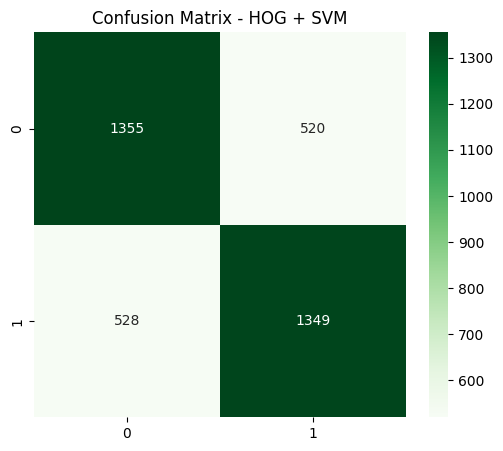

In [23]:
import seaborn as sns
cm = confusion_matrix(y_val_hog, y_pred)


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - HOG + SVM")
plt.show()

### Results of the Final Model

The final accuracy is about 72%, which is a clear improvement over the baseline model.

This confirms that the choice of a more informative feature representation was essential.

The improvement can be explained by the fact that HOG captures edge and shape information, which is more useful for distinguishing cats and dogs.


In [12]:
import joblib

save_folder = "/content/drive/MyDrive/Datamachinelearning/data"
model = joblib.load(save_folder + "/final_cats_dogs_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [17]:
import cv2
import numpy as np
from skimage.feature import hog

def cats_dogs_classification(image):

    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    image = cv2.resize(image, (64, 64))

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    features = features.reshape(1, -1)

    prediction = model.predict(features)[0]

    return int(prediction)

### Final Prediction Function

The function cats_dogs_classification(image) applies the same preprocessing steps used during training:

1. convert the input image to grayscale
2. resize it to 64 × 64
3. extract HOG features with the same parameters
4. pass the feature vector to the trained model
5. return:
   - 0 for cat
   - 1 for dog


In [18]:
test_img_path = image_paths[0]

img = cv2.imread(test_img_path)
pred = cats_dogs_classification(img)

print("Predicted label:", pred)
print("Predicted class:", "Cat" if pred == 0 else "Dog")

Predicted label: 0
Predicted class: Cat


# Addition: Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_hog, y_train_hog)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_rf = rf_model.predict(X_val_hog)

print("Validation Accuracy:", accuracy_score(y_val_hog, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_val_hog, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val_hog, y_pred_rf))

Validation Accuracy: 0.712953091684435

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.77      0.73      1875
           1       0.74      0.66      0.70      1877

    accuracy                           0.71      3752
   macro avg       0.72      0.71      0.71      3752
weighted avg       0.72      0.71      0.71      3752


Confusion Matrix:

[[1442  433]
 [ 644 1233]]


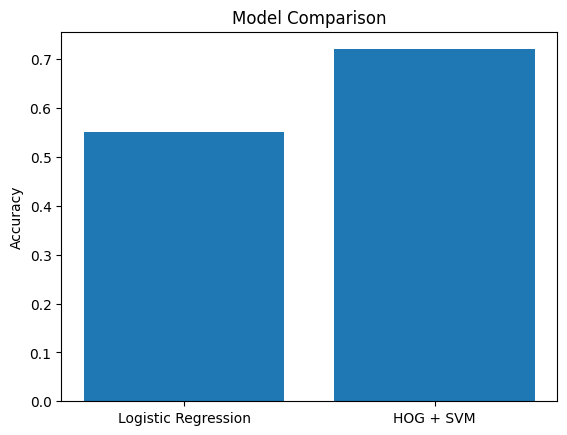

In [25]:
models = ['Logistic Regression', 'HOG + SVM']
accuracies = [0.55, 0.72]

plt.figure()
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

# Conclusion:
In this project, I have tested two main approaches

The first approach used raw pixel values with Logistic Regression. This simple baseline achieved limited performance, showing that raw pixels are not sufficiently informative for this task.

The second approach used HOG feature extraction combined with PCA and a Linear SVM. This significantly improved the results and provided a better balance between accuracy and computational cost.

This approach satisfies the project constraints and provides a solid classical machine learning solution for cats vs dogs recognition.